# How to run a simulation against a candidate panel

A **simulation run** takes a persisted candidate panel — the pairs, hedge weights, and mean-reversion diagnostics produced in [notebook 01](01_create_candidate_panel.ipynb) — and walks it forward through time as an actual trading strategy: at each date it z-scores each candidate spread, opens positions when the z-score is extreme, sizes and risk-limits them, and closes them as the spread mean-reverts. It returns a `SimulationResult` with the closed trades, daily portfolio equity, and a performance summary.

This is the **cheap step run many times** side of the panel/simulation split: building a panel (residual fits + candidate scoring) is expensive and done once, but a panel is then simulated against *many* strategy configs (different `entry_z`, sizing, risk limits, …) during research. This notebook runs **one** such config against the committed `materials_v1` fixture panel.

The entry point is `run_from_config(SimulatorConfig) -> SimulationResult` from `src.simulator.simulator_factory` — the same call `run_me.py`'s `simulate` stage makes.

## The minimal knobs for a run

Most of a `SimulatorConfig` is boilerplate we lean on the repo's **`standard_v1`** defaults bundle for (`get_default_bundle("standard_v1")` in `src.simulator.sweep_defaults` — capital, candidate selection, activation, MR diagnostics, execution, performance, persistence). The knobs an experiment actually varies between runs:

| knob | controls | this run |
| --- | --- | --- |
| `entry_z` | abs z-score threshold to **open** a pair position | `1.75` |
| `exit_z` | z-score to **close** (mean-reversion target) | `0.0` |
| `z_lookback` / `z_method` | z-score window and estimator (`ewm` or `rolling`) | `126` / `ewm` |
| `residual_key` | which residual timescale to trade — **must match the panel's `meta.json` residual key** (links `ZScoreConfig` to the persisted panel) | `exp_hl504_mh1008_rf` |
| `base_pair_notional` | $ notional per pair leg-set | `100_000` |
| run window (`start_date`/`end_date`) | date range to simulate — capped here purely to keep the notebook fast | `2018-01-01 → 2020-12-31` |

`entry_z` is the one knob you always set. `residual_key` is the critical linkage: `exp_hl504_mh1008_rf` is the `CausalResidualConfig.key` recorded in the fixture panel's `meta.json`; the simulator matches the `ZScoreConfig.residual_key` against it to pick which panel to trade. This notebook never constructs a `CausalResidualConfig` directly — it consumes the panel already built in notebook 01 by its persisted `residual_key` string.

In [1]:
# ── knobs ────────────────────────────────────────────────────────────────
ENTRY_Z      = 1.75
EXIT_Z       = 0.0
Z_LOOKBACK   = 126
Z_METHOD     = "ewm"
RESIDUAL_KEY = "exp_hl504_mh1008_rf"   # must match the panel's meta.json residual key
BASE_PAIR_NOTIONAL = 100_000.0

# Run window — capped so the notebook runs in ~1 min (like max_steps in nb 01).
# Drop these (set to None) to simulate the panel's full history.
WINDOW_START = "2018-01-01"
WINDOW_END   = "2020-12-31"

PANEL_SUBDIR = "howto_sim"             # working dir under CANDIDATE_PANELS_ROOT

## Setup: stage the fixture panel where the simulator looks for it

The simulator discovers panels under `CANDIDATE_PANELS_ROOT/<subdir>` (globbing `{sector}_pairs_*.panel.parquet` and reading each `meta.json` for its residual key). So we copy the committed `materials_v1` fixture triple — `.panel.parquet`, `.meta.json`, `_residual_params.pkl` — into a working subdir.

Two prep steps mirror what `run_me.py`'s `residuals`/`simulate` stages do:
- **Slice the panel to the run window** and re-save it — the sliced panel bounds how many candidate/date series we compute below, keeping the notebook fast.
- **Persist spread-level series** (`compute_and_persist_series`) so the simulator loads spread levels from disk instead of recomputing residuals on every step (the difference between ~1 min and many minutes).

In [2]:
import shutil, pickle
from pathlib import Path
import pandas as pd

from src.settings import CANDIDATE_PANELS_ROOT, DATA_UNIVERSES, PROJECT_ROOT
from src.candidates.candidate_panel import (
    load_candidate_panel_result, save_candidate_panel_result, CandidatePanelResult,
)
from src.residuals.series import compute_and_persist_series
from src.simulator.config import DataConfig
from src.simulator.simulator_factory import _load_umd

FIXTURE_DIR = PROJECT_ROOT / "fixtures" / "materials_v1"
STEM = "mat_pairs_pca_W-FRI_exp_hl504_20260530_1400"
panel_dir = Path(CANDIDATE_PANELS_ROOT) / PANEL_SUBDIR

# 1. stage the fixture panel triple into the discovery location
shutil.rmtree(panel_dir, ignore_errors=True)
panel_dir.mkdir(parents=True, exist_ok=True)
for suffix in (".panel.parquet", ".meta.json", "_residual_params.pkl"):
    shutil.copy2(FIXTURE_DIR / f"{STEM}{suffix}", panel_dir / f"{STEM}{suffix}")

# 2. slice the panel to the run window and re-save (bounds the series work below)
loaded = load_candidate_panel_result(out_dir=panel_dir, stem=STEM)
asof = pd.to_datetime(loaded.panel["asof_date"])
mask = (asof >= WINDOW_START) & (asof <= WINDOW_END)
sliced = loaded.panel[mask].reset_index(drop=True)
save_candidate_panel_result(CandidatePanelResult(panel=sliced, metadata=loaded.metadata),
                            out_dir=panel_dir, stem=STEM)
print(f"panel sliced to {WINDOW_START}..{WINDOW_END}: {len(sliced)} candidate rows "
      f"({sliced['asof_date'].nunique()} dates x {sliced['spread_id'].nunique()} spreads)")

# 3. precompute + persist spread-level series (params keyed (group_id, '') — single timescale)
with open(panel_dir / f"{STEM}_residual_params.pkl", "rb") as f:
    raw_params = pickle.load(f)
residual_params = {(str(g), ""): raw_params for g in sliced["group_id"].unique()}
umd = _load_umd(DataConfig(candidate_panel_subdir=PANEL_SUBDIR, selected_sectors=["materials"],
                           data_path=str(DATA_UNIVERSES)))
compute_and_persist_series(panel_dir=panel_dir, candidate_panel=sliced,
                           residual_params=residual_params, market_data=umd)
print("spread-level series persisted under", panel_dir / "series")

panel sliced to 2018-01-01..2020-12-31: 12168 candidate rows (156 dates x 78 spreads)
[discover] Found 1 sectors: ['mat']
[factory] Loading 1 universe(s)...
Loading universe materials_only_v1...
QCWarning(ticker='APD', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='AVY', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='BALL', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='CF', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='IFF', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='IP', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='NUE', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='SHW', issue='open_outside_range', details='1 rows where Open

[series] stock residuals: 0ticker [00:00, ?ticker/s]

[series] stock residuals: 0ticker [00:00, ?ticker/s]

[series] spread levels:   0%|          | 0/12168 [00:00<?, ?spread/s]

[series] spread levels:   0%|          | 52/12168 [00:00<00:23, 519.26spread/s]

...

[series] spread levels:  98%|█████████▊| 11922/12168 [00:17<00:00, 700.77spread/s]

[series] spread levels:  99%|█████████▊| 11993/12168 [00:17<00:00, 693.29spread/s]

[series] spread levels:  99%|█████████▉| 12063/12168 [00:17<00:00, 683.21spread/s]

[series] spread levels: 100%|██████████| 12168/12168 [00:17<00:00, 685.61spread/s]

[series] Persisted 0 stock and 11778 spread series under /home/nikolajnock/PycharmProjects/statarb_sim/artifacts/candidate_panels/howto_sim/series (existing files skipped).
spread-level series persisted under /home/nikolajnock/PycharmProjects/statarb_sim/artifacts/candidate_panels/howto_sim/series


## Build the config and run

We assemble a `SimulatorConfig` from the knobs plus the `standard_v1` defaults bundle, overriding only `persistence` (this is an ad-hoc run — no run dir) and pointing the QuantStats HTML report at the artifacts dir. Then `run_from_config` loads the panel + residual params, builds the simulator, and walks it forward — printing the performance metrics table when it finishes.

In [3]:
from src.settings import PERFORMANCE_REPORTS
from src.simulator.config import (
    SimulatorConfig, ZScoreConfig, PairSpreadTraderConfig, RunConfig,
    SizingConfig, VolSizingConfig, RiskManagerConfig, PerformanceConfig, PersistenceConfig,
)
from src.simulator.sweep_defaults import get_default_bundle
from src.simulator.simulator_factory import run_from_config

# lean on standard_v1 for the boilerplate sub-configs; customise perf output + persistence
defaults = dict(get_default_bundle("standard_v1"))
defaults["performance"] = PerformanceConfig(
    enabled=True, metrics_table=True, report_html=True,
    report_output_dir=str(PERFORMANCE_REPORTS), per_group_breakdown=True,
)
defaults["persistence"] = PersistenceConfig(enabled=False)   # ad-hoc run, no run dir

config = SimulatorConfig(
    data=DataConfig(
        candidate_panel_subdir=PANEL_SUBDIR, selected_sectors=["materials"],
        data_path=str(DATA_UNIVERSES), price_field="Close", return_method="log",
    ),
    z_score=ZScoreConfig(lookback=Z_LOOKBACK, method=Z_METHOD, residual_key=RESIDUAL_KEY),
    trader=PairSpreadTraderConfig(entry_z=ENTRY_Z, exit_z=EXIT_Z),
    sizing=SizingConfig(base_pair_notional=BASE_PAIR_NOTIONAL, vol_normalize=VolSizingConfig()),
    risk_manager=RiskManagerConfig(max_gross_exposure=10.0, max_ticker_exposure_pct=0.15),
    run=RunConfig(start_date=WINDOW_START, end_date=WINDOW_END, progress=False),
    **defaults,
)

result = run_from_config(config)

[run] Loading universe market data...
[discover] Found 1 sectors: ['mat']
[factory] Loading 1 universe(s)...
Loading universe materials_only_v1...
QCWarning(ticker='APD', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='AVY', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='BALL', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='CF', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='IFF', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='IP', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='NUE', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='SHW', issue='open_outside_range', details='1 rows where Open is outside [Low, High]')
QCWarning(ticker='SPY'

[mem] step=100 719 MB | closed_trades=16 | action_log=49 | daily_state=1592 | portfolio_state=99 | snapshots=17


[mem] step=200 1061 MB | closed_trades=32 | action_log=75 | daily_state=3131 | portfolio_state=199 | snapshots=11


[mem] step=300 1377 MB | closed_trades=52 | action_log=117 | daily_state=5141 | portfolio_state=299 | snapshots=13


[mem] step=400 1394 MB | closed_trades=53 | action_log=135 | daily_state=7152 | portfolio_state=399 | snapshots=29


[mem] step=500 1395 MB | closed_trades=69 | action_log=152 | daily_state=9722 | portfolio_state=499 | snapshots=14


[mem] step=600 1396 MB | closed_trades=91 | action_log=207 | daily_state=11853 | portfolio_state=599 | snapshots=25


[mem] step=700 1400 MB | closed_trades=105 | action_log=231 | daily_state=14095 | portfolio_state=699 | snapshots=21



────────────────────────────────────────────────────
  Strategy Performance
────────────────────────────────────────────────────
  Total Return (Net)                          1.62%
  Total Return (Gross)                        2.95%
  Annual Return (Net)                         0.54%
  Annual Return (Gross)                       0.99%
  Sharpe Ratio (Net)                          0.327
  Sortino Ratio (Net)                         0.399
  Sortino Ratio (Gross)                       0.402
  Calmar Ratio (Net)                          0.008
  Max Drawdown (Net)                        -68.57%
  Max Drawdown (Gross)                      -67.95%
  # Trades                                      117
  # Groups Traded                                 1
  # Trading Days                                748
  Avg Concurrent Positions                    20.34
  Avg Holding Period (days)                   105.3
  Avg Holding — Wins (days)                    76.0
  Avg Holding — Losses (days)         


[performance] HTML report written to: /home/nikolajnock/PycharmProjects/statarb_sim/artifacts/performance_reports/strategy_performance_quantstats.html


## Inspect the results

`run_from_config` returns a `SimulationResult`. The confirmation that this is a *real* run (not a no-op) is `closed_trades`; `result.performance` is a `PerformanceResult` (`.metrics`, `.group_metrics`, `.returns_net`), and there are DataFrame accessors (`closed_trades_df()`, `daily_portfolio_state_df()`, …) for drilling in.

In [4]:
print(f"closed trades: {len(result.closed_trades)}")

m = result.performance.metrics
for k in ["n_trades", "win_rate_net", "sharpe_net", "total_net_pnl", "max_drawdown_net"]:
    if k in m:
        print(f"  {k:18s}: {m[k]}")

# a few closed trades
trades = result.closed_trades_df()
cols = [c for c in ["group_id", "spread_id", "entry_date", "exit_date",
                    "net_pnl", "entry_z_score", "exit_z_score"] if c in trades.columns]
trades[cols].head()

closed trades: 117
  n_trades          : 117
  win_rate_net      : 0.6923076923076923
  sharpe_net        : 0.3269008218742559
  total_net_pnl     : -1148.7175450597788
  max_drawdown_net  : -0.6857144514655313


,group_id,spread_id,entry_date,exit_date,entry_z_score,exit_z_score
0,materials,BALL|IP,2018-01-05,2018-03-07,-1.852581,0.478979
1,materials,AVY|ECL,2018-01-08,2018-03-23,1.823411,-0.012477
2,materials,CF|ECL,2018-01-10,2018-03-23,1.814476,-0.018272
3,materials,ECL|PPG,2018-01-10,2018-03-23,-1.761752,0.056982
4,materials,ECL|LIN,2018-01-08,2018-03-27,-1.833641,0.152146


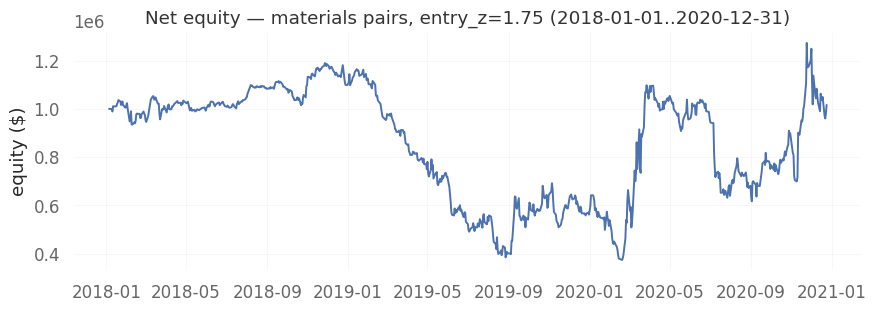

In [5]:
# equity curve from the daily portfolio state log
import matplotlib.pyplot as plt

dps = result.daily_portfolio_state_df()
dps["date"] = pd.to_datetime(dps["date"])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(dps["date"], dps["total_equity_net"], lw=1.4)
ax.set_title(f"Net equity — materials pairs, entry_z={ENTRY_Z} ({WINDOW_START}..{WINDOW_END})")
ax.set_ylabel("equity ($)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Where the outputs go, and running many configs

- **Performance summary** — the metrics table printed above comes from the repo's standard reporter (`src.simulator.performance.performance_report.generate_report`), which also writes a **QuantStats HTML tearsheet** to `artifacts/performance_reports/` (`report_html=True`).
- **Persisting a run** — we set `PersistenceConfig(enabled=False)` for this ad-hoc run. Enabling it (as `run_me.py` does, with `output_dir` under `SIMULATION_RUNS_ROOT`) writes the full run — config, logs, closed trades, metrics — to a timestamped run dir for later comparison.
- **Sweeps** — to run *many* configs against this one panel, vary the knobs (e.g. `entry_z`) and call `run_from_config` again; the panel and its persisted series are reused untouched. The batch machinery for this lives in `src.simulator.sweep_runner`.

The full-history run is the same code with `WINDOW_START = WINDOW_END = None` (slower — it simulates all ~870 panel dates).